### Step1:  Importing necessary libraries

In [1]:
import torch, torchdata, torchtext
import torch.nn as nn
import torch.nn.functional as F

import random, math, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

#make our work comparable if restarted the kernel
SEED = 1234
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True

/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
torch.__version__,torchtext.__version__

('2.1.2+cu121', '0.16.2+cpu')

#### Task 1: Language Pair Selection and Dataset Description

For this machine translation task, a Nepali–English parallel corpus was selected, as Nepali is the native language of the study.

Dataset Used

- Name: ne-en-parallel-208k
- Source: Hugging Face Datasets
- Repository: sharad461/ne-en-parallel-208k
- Link: https://huggingface.co/datasets/sharad461/ne-en-parallel-208k

Dataset Description
- The dataset contains approximately 208,000 aligned Nepali–English sentence pairs, where each English sentence is paired with its Nepali translation. Its clean structure and parallel alignment make it suitable for supervised neural machine translation tasks.

In [3]:
from datasets import load_dataset

# Load the Nepali–English parallel dataset from Hugging Face
# This downloads the dataset and prepares it in a structured format
dataset = load_dataset("sharad461/ne-en-parallel-208k")

# Print dataset splits and basic metadata
# This helps verify how the data is divided (e.g., train, validation, test)
print(dataset)

# Display the column names of the training split
# This confirms the available fields (e.g., 'en' for English and 'ne' for Nepali)
print("Columns:", dataset["train"].column_names)

# Print the first training example
# This allows inspection of a sample parallel sentence pair
print("Example:", dataset["train"][0])


DatasetDict({
    train: Dataset({
        features: ['ne', 'en'],
        num_rows: 208831
    })
})
Columns: ['ne', 'en']
Example: {'ne': 'दाऊदले अमालेकीहरूलाई हराएर पछि सिकलग गए। यो शाऊलको मृत्यु भएको केही दिन पछिको कुरा हो। दाऊद त्यहाँ दुइ दिन बसे।', 'en': 'It happened after the death of Saul, when David was returned from the slaughter of the Amalekites, and David had stayed two days in Ziklag;'}


In [4]:
#Split train/val/test (70/20/10)
split_1 = dataset["train"].train_test_split(test_size=0.3, seed=999)     # 70% train, 30% temp
split_2 = split_1["test"].train_test_split(test_size=1/3, seed=999)      # from temp: 20% val, 10% test

# train_ds = split_1["train"]
# val_ds   = split_2["train"]
# test_ds  = split_2["test"]

train_ds = split_1["train"]
val_ds   = split_2["train"]
test_ds  = split_2["test"]

print("sizes:", len(train_ds), len(val_ds), len(test_ds))

# after you create train_ds / val_ds / test_ds
train_ds = train_ds.shuffle(seed=999).select(range(5000))
val_ds   = val_ds.shuffle(seed=999).select(range(500))
test_ds = test_ds.shuffle(seed=999).select(range(1000))


sizes: 146181 41766 20884


#### Task 2: Dataset Preparation and Preprocessing

The dataset preparation process followed a structured workflow to ensure suitability for training a neural machine translation model. A Nepali–English parallel corpus was first loaded from Hugging Face, providing aligned sentence pairs in both languages. The dataset included predefined training, validation, and test splits, allowing it to be integrated directly into the preprocessing pipeline. Details of the dataset source were documented earlier as part of the ETL stage.

During initial exploratory analysis, the dataset structure was examined and minor adjustments were made to simplify subsequent processing steps. To reduce computational overhead and enable faster experimentation, a randomly sampled subset of the original training data was selected while maintaining linguistic diversity.

- Tokenization

Given the bilingual nature of the task and the distinct linguistic characteristics of each language, separate tokenization strategies were applied. English sentences were tokenized using spaCy’s pretrained tokenizer accessed through TorchText’s get_tokenizer, which effectively handles punctuation and standard linguistic patterns. For Nepali, a WordPiece-based subword tokenizer from the nepalitokenizers library was employed. This approach is well-suited to Nepali’s rich morphology, as subword tokenization reduces vocabulary sparsity and improves robustness to rare word forms.

English Tokenization: spaCy tokenizer via TorchText

Nepali Tokenization: WordPiece tokenizer from the nepalitokenizers library

The nepalitokenizers library was developed by Soyuj Basnet using Hugging Face’s tokenizers framework
(Source: https://github.com/basnetsoyuj/nepali-tokenizers
)

To support sequence-to-sequence modeling, several special tokens were introduced:

<unk> for unknown tokens

<pad> for sequence padding

<sos> to indicate the start of a sentence

<eos> to indicate the end of a sentence

These symbols are essential for both model training and inference.

Numericalization

Finally, numericalization was performed using TorchText’s build_vocab_from_iterator, converting tokenized text into integer indices based on language-specific vocabularies. This transformation produced numerical representations suitable for downstream steps such as batching, padding, and input to the Transformer-based translation model.

### Step2: Tokenizing

In [5]:
from torchtext.data.utils import get_tokenizer
from nepalitokenizers import WordPiece

# Define source and target language codes
# 'en' represents English (source language)
# 'ne' represents Nepali (target language)
SRC_LANG  = "en"
TARG_LANG = "ne"

# Dictionaries to store tokenizers and vocabularies for each language
token_transform = {}
vocab_transform = {}

# -----------------------------
# English Tokenization
# -----------------------------
# Use spaCy's pretrained English tokenizer via TorchText
# This tokenizer handles punctuation, contractions, and common English patterns
# NOTE: Requires the spaCy model 'en_core_web_sm' to be installed
token_transform[SRC_LANG] = get_tokenizer(
    "spacy",
    language="en_core_web_sm"
)

# -----------------------------
# Nepali Tokenization
# -----------------------------
# Use a WordPiece subword tokenizer from the nepalitokenizers library
# WordPiece is effective for Nepali due to its rich morphology
# Subword tokenization reduces vocabulary size and handles rare words better
wp = WordPiece()
token_transform[TARG_LANG] = wp


In [6]:
ex = train_ds[0]
print("EN:", ex[SRC_LANG])
print("NE:", ex[TARG_LANG])
print("EN tokens:", token_transform[SRC_LANG](ex[SRC_LANG].lower()))
print("NE tokens:", token_transform[TARG_LANG].encode(ex[TARG_LANG].lower()).tokens)

EN: Configure xsldbg's Walk Speed
NE: xsldbg' s हिँडाई गति कन्फिगर गर्नुहोस्
EN tokens: ['configure', 'xsldbg', "'s", 'walk', 'speed']
NE tokens: ['[CLS]', 'x', '##s', '##ld', '##b', '##g', "'", 's', 'हिँड', '##ाई', 'गति', 'कन्फ', '##िग', '##र', 'गर्नुहोस्', '[SEP]']


In [7]:
# ---------------------------------------------------------
# Tokenization Function
# ---------------------------------------------------------
# This function tokenizes a single dataset example based on
# the specified language (English or Nepali).
# It returns a new column containing tokenized text.
def add_tokens(example, lang):
    if lang == "en":
        # Convert English text to lowercase and tokenize using spaCy
        # spaCy handles punctuation and common English linguistic patterns
        return {
            f"{lang}_tok": token_transform[lang](example[lang].lower())
        }
    else:  # lang == "ne"
        # Convert Nepali text to lowercase and tokenize using WordPiece
        # The WordPiece tokenizer outputs subword tokens
        return {
            f"{lang}_tok": token_transform[lang]
            .encode(example[lang].lower())
            .tokens
        }

# ---------------------------------------------------------
# Apply Tokenization to Training Dataset
# ---------------------------------------------------------
# Tokenize English sentences in the training split
train_tok = train_ds.map(add_tokens, fn_kwargs={"lang": SRC_LANG})

# Tokenize Nepali sentences in the training split
train_tok = train_tok.map(add_tokens, fn_kwargs={"lang": TARG_LANG})

# ---------------------------------------------------------
# Apply Tokenization to Validation Dataset
# ---------------------------------------------------------
# Tokenize English sentences in the validation split
val_tok = val_ds.map(add_tokens, fn_kwargs={"lang": SRC_LANG})

# Tokenize Nepali sentences in the validation split
val_tok = val_tok.map(add_tokens, fn_kwargs={"lang": TARG_LANG})

# ---------------------------------------------------------
# Apply Tokenization to Test Dataset
# ---------------------------------------------------------
# Tokenize English sentences in the test split
test_tok = test_ds.map(add_tokens, fn_kwargs={"lang": SRC_LANG})

# Tokenize Nepali sentences in the test split
test_tok = test_tok.map(add_tokens, fn_kwargs={"lang": TARG_LANG})

# ---------------------------------------------------------
# Verification and Inspection
# ---------------------------------------------------------
# Confirm that tokenized columns (e.g., 'en_tok', 'ne_tok')
# have been successfully added to the dataset
print("Token columns:", [c for c in train_tok.column_names if c.endswith("_tok")])

# Display a small sample of tokenized English and Nepali text
# This helps verify correct tokenization for both languages
print(
    "Token example:",
    train_tok[0][f"{SRC_LANG}_tok"][:10],
    "|",
    train_tok[0][f"{TARG_LANG}_tok"][:10]
)


Map: 100%|██████████| 1000/1000 [00:00<00:00, 12311.53 examples/s]

Token columns: ['en_tok', 'ne_tok']
Token example: ['configure', 'xsldbg', "'s", 'walk', 'speed'] | ['[CLS]', 'x', '##s', '##ld', '##b', '##g', "'", 's', 'हिँड', '##ाई']


In [8]:
# Define special symbols and indices
UNK_IDX, PAD_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
# Make sure the tokens are in order of their indices to properly insert them in vocab
special_symbols = ['<unk>', '<pad>', '<sos>', '<eos>']

### Step3: Text to integers (Numericalization)

In [9]:
from torchtext.vocab import build_vocab_from_iterator

# ---------------------------------------------------------
# Token Generator Function
# ---------------------------------------------------------
# This generator yields tokenized sentences one at a time
# It allows TorchText to build vocabularies efficiently
# without loading all tokens into memory at once
def yield_tokens_from_split(ds, tok_col):
    for tokens in ds[tok_col]:
        yield tokens

# ---------------------------------------------------------
# Build Vocabulary for Source Language (English)
# ---------------------------------------------------------
# Create a vocabulary from tokenized English training data
# - Tokens appearing fewer than 2 times are discarded to reduce noise
# - Special symbols (<unk>, <pad>, <sos>, <eos>) are added at fixed indices
# - 'special_first=True' ensures special tokens occupy the lowest indices
vocab_transform[SRC_LANG] = build_vocab_from_iterator(
    yield_tokens_from_split(train_tok, f"{SRC_LANG}_tok"),
    min_freq=2,
    specials=special_symbols,
    special_first=True
)

# ---------------------------------------------------------
# Build Vocabulary for Target Language (Nepali)
# ---------------------------------------------------------
# Create a vocabulary from tokenized Nepali training data
# Using the same settings ensures consistency across languages
vocab_transform[TARG_LANG] = build_vocab_from_iterator(
    yield_tokens_from_split(train_tok, f"{TARG_LANG}_tok"),
    min_freq=2,
    specials=special_symbols,
    special_first=True
)

# ---------------------------------------------------------
# Handle Out-of-Vocabulary Tokens
# ---------------------------------------------------------
# Map any unseen or rare tokens to the <unk> token
# This prevents errors during numericalization
vocab_transform[SRC_LANG].set_default_index(UNK_IDX)
vocab_transform[TARG_LANG].set_default_index(UNK_IDX)

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
# Print vocabulary sizes for English and Nepali
# This helps verify vocabulary construction and pruning
print("EN vocab size:", len(vocab_transform[SRC_LANG]))
print("NE vocab size:", len(vocab_transform[TARG_LANG]))


EN vocab size: 5251
NE vocab size: 7631


In [10]:
# Save vocab
torch.save(vocab_transform, "model/vocab.pt")


In [11]:
#see some example
vocab_transform[SRC_LANG](['here', 'is', 'a', 'unknownword', 'a'])

[339, 20, 11, 0, 11]

In [12]:
#we can reverse it....
mapping = vocab_transform[SRC_LANG].get_itos()

#print 1816, for example
mapping[1891]

'arise'

In [13]:
#let's try unknown vocab
mapping[0]
#they will all map to <unk> which has 0 as integer

'<unk>'

In [14]:
#let's try special symbols
mapping[1], mapping[2], mapping[3]

('<pad>', '<sos>', '<eos>')

In [15]:
#check unique vocabularies
len(mapping)

5251

### Step 4: Preparing the dataloader

In [16]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import torch

BATCH_SIZE = 64

# ---------------------------------------------------------
# Helper Function: Sequential Transforms
# ---------------------------------------------------------
# This function composes multiple preprocessing steps
# (tokenization → numericalization → tensor conversion)
# into a single callable transformation.
def sequential_transforms(*transforms):
    def func(txt_input):
        # Apply each transform sequentially to the input text
        for transform in transforms:
            try:
                # Apply transform directly (e.g., tokenizer or vocab lookup)
                txt_input = transform(txt_input)
            except:
                # Handle tokenizers that require explicit encoding (e.g., WordPiece)
                txt_input = transform.encode(txt_input).tokens
        return txt_input
    return func


# ---------------------------------------------------------
# Tensor Transformation
# ---------------------------------------------------------
# Adds special tokens for start-of-sequence (SOS)
# and end-of-sequence (EOS), then converts the
# token indices into a PyTorch tensor.
def tensor_transform(token_ids):
    return torch.cat((
        torch.tensor([SOS_IDX]),
        torch.tensor(token_ids),
        torch.tensor([EOS_IDX])
    ))


# ---------------------------------------------------------
# Text Transformation Pipeline (per language)
# ---------------------------------------------------------
# This dictionary maps each language to a complete
# preprocessing pipeline:
#   1. Tokenization
#   2. Numericalization (token → index)
#   3. BOS/EOS insertion and tensor creation
text_transform = {}
for ln in [SRC_LANG, TARG_LANG]:
    text_transform[ln] = sequential_transforms(
        token_transform[ln],    # Tokenization
        vocab_transform[ln],    # Numericalization
        tensor_transform        # Add BOS/EOS and convert to tensor
    )


# ---------------------------------------------------------
# Collate Function for DataLoader
# ---------------------------------------------------------
# This function prepares a batch of samples by:
# - Applying text transformations
# - Padding sequences to equal length
# - Recording original source sequence lengths
def collate_batch(batch):
    src_batch, src_len_batch, trg_batch = [], [], []

    for item in batch:
        # Process source sentence
        processed_src = text_transform[SRC_LANG](item[SRC_LANG])
        src_batch.append(processed_src)

        # Process target sentence
        trg_batch.append(text_transform[TARG_LANG](item[TARG_LANG]))

        # Store original source length (useful for masking)
        src_len_batch.append(processed_src.size(0))

    # Pad source sequences to the same length
    # batch_first=True gives shape [batch_size, seq_len]
    src_batch = pad_sequence(
        src_batch,
        padding_value=PAD_IDX,
        batch_first=True
    )

    # Pad target sequences
    trg_batch = pad_sequence(
        trg_batch,
        padding_value=PAD_IDX,
        batch_first=True
    )

    # Return padded batches and source lengths
    return (
        src_batch,
        torch.tensor(src_len_batch, dtype=torch.int64),
        trg_batch
    )


# Create train, val, and test dataloaders

In [17]:
# Set the batch size for data loaders
batch_size = 64

# Creating DataLoader for the training, validation, test set
train_loader = DataLoader(train_tok, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(val_tok,   batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_tok,  batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

In [18]:
for ne, _, en in train_loader:
    break

In [19]:
print("English shape: ", en.shape)  # (batch_size, seq len)
print("Nepali shape: ", ne.shape)   # (batch_size, seq len)

English shape:  torch.Size([64, 77])
Nepali shape:  torch.Size([64, 64])


### Step5: Designing the model

#### Encoder Layer

In [20]:
class EncoderLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, pf_dim, dropout, atten_type, device):
        super().__init__()
        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm        = nn.LayerNorm(hid_dim)
        self.self_attention       = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, atten_type, device)
        self.feedforward          = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)
        self.dropout              = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        #src = [batch size, src len, hid dim]
        #src_mask = [batch size, 1, 1, src len]   #if the token is padding, it will be 1, otherwise 0
        _src, _ = self.self_attention(src, src, src, src_mask)
        src     = self.self_attn_layer_norm(src + self.dropout(_src))
        #src: [batch_size, src len, hid dim]

        _src    = self.feedforward(src)
        src     = self.ff_layer_norm(src + self.dropout(_src))
        #src: [batch_size, src len, hid dim]

        return src

#### Encoder

In [21]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hid_dim, n_layers, n_heads, pf_dim, dropout, atten_type, device, max_length = 5000):
        super().__init__()
        self.device = device
        self.atten_type = atten_type
        self.tok_embedding = nn.Embedding(input_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)
        self.layers        = nn.ModuleList([EncoderLayer(hid_dim, n_heads, pf_dim, dropout, atten_type,device)
                                           for _ in range(n_layers)])
        self.dropout       = nn.Dropout(dropout)
        self.scale         = torch.sqrt(torch.FloatTensor([hid_dim])).to(self.device)
        
    def forward(self, src, src_mask):
        
        #src = [batch size, src len]
        #src_mask = [batch size, 1, 1, src len]
        
        batch_size = src.shape[0]
        src_len    = src.shape[1]
        
        pos        = torch.arange(0, src_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)
        #pos: [batch_size, src_len]
        
        src        = self.dropout((self.tok_embedding(src) * self.scale) + self.pos_embedding(pos))
        #src: [batch_size, src_len, hid_dim]
        
        for layer in self.layers:
            src = layer(src, src_mask)
        #src: [batch_size, src_len, hid_dim]
        
        return src

#### General additive layer

#### Additive Attention

In [22]:
class AdditiveAttention(nn.Module):
    def __init__(self, head_dim):
        super(AdditiveAttention, self).__init__()
        
        # Linear layers for additive attention
        self.Wa = nn.Linear(head_dim, head_dim)
        self.Ua = nn.Linear(head_dim, head_dim)
        self.V = nn.Linear(head_dim, 1)

    def forward(self, query, keys):
        # Add singleton dimensions for broadcasting
        query = query.unsqueeze(3)
        keys = keys.unsqueeze(2)

        # Apply additive attention mechanism
        features = torch.tanh(self.Wa(query) + self.Ua(keys))
        
        # Calculate attention scores
        scores = self.V(features).squeeze(-1)
        
        return scores

In [23]:
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, atten_type, device):
        super().__init__()
        assert hid_dim % n_heads == 0
        self.hid_dim  = hid_dim
        self.n_heads  = n_heads
        self.head_dim = hid_dim // n_heads
        self.atten_type = atten_type
        
        self.fc_q     = nn.Linear(hid_dim, hid_dim)
        self.fc_k     = nn.Linear(hid_dim, hid_dim)
        self.fc_v     = nn.Linear(hid_dim, hid_dim)
        
        self.fc_o     = nn.Linear(hid_dim, hid_dim)
        
        self.dropout  = nn.Dropout(dropout)
        
        self.scale    = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)
        self.additive_attention = AdditiveAttention(self.head_dim)
                
    def forward(self, query, key, value, mask = None):
        #src, src, src, src_mask
        #query = [batch size, query len, hid dim]
        #key = [batch size, key len, hid dim]
        #value = [batch size, value len, hid dim]
        
        batch_size = query.shape[0]
        
        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)
        #Q=K=V: [batch_size, src len, hid_dim]
        
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        #Q = [batch_size, n heads, query len, head_dim]

        # Calculate attention scores based on the selected attention variant
        if self.atten_type == "general":
            energy = torch.matmul(Q, K.permute(0, 1, 3, 2))
        elif self.atten_type == "additive":
            energy = self.additive_attention(Q, K)
        else:
            raise Exception("Incorrect value. Must be either 'multiplicative', 'general', or 'additive'.")
        
        #Q = [batch_size, n heads, query len, head_dim] @ K = [batch_size, n heads, head_dim, key len]
        #energy = [batch_size, n heads, query len, key len]
        
        #for making attention to padding to 0
        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)
            
        attention = torch.softmax(energy, dim = -1)
        #attention = [batch_size, n heads, query len, key len]
        
        x = torch.matmul(self.dropout(attention), V)
        #[batch_size, n heads, query len, key len] @ [batch_size, n heads, value len, head_dim]
        #x = [batch_size, n heads, query len, head dim]
        
        x = x.permute(0, 2, 1, 3).contiguous()  #we can perform .view
        #x = [batch_size, query len, n heads, head dim]
        
        x = x.view(batch_size, -1, self.hid_dim)
        #x = [batch_size, query len, hid dim]
        
        x = self.fc_o(x)
        #x = [batch_size, query len, hid dim]
        
        return x, attention

#### Position-wise Feedforward Layer

In [24]:
class PositionwiseFeedforwardLayer(nn.Module):
    def __init__(self, hid_dim, pf_dim, dropout):
        super().__init__()
        self.fc1 = nn.Linear(hid_dim, pf_dim)
        self.fc2 = nn.Linear(pf_dim, hid_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        #x = [batch size, src len, hid dim]
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

#### Decoder Layer

In [25]:
class DecoderLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, pf_dim, dropout, atten_type, device):
        super().__init__()
        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.enc_attn_layer_norm  = nn.LayerNorm(hid_dim)
        self.ff_layer_norm        = nn.LayerNorm(hid_dim)
        self.self_attention       = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, atten_type, device)
        self.encoder_attention    = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, atten_type, device)
        self.feedforward          = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)
        self.dropout              = nn.Dropout(dropout)
        
    def forward(self, trg, enc_src, trg_mask, src_mask):
        
        #trg = [batch size, trg len, hid dim]
        #enc_src = [batch size, src len, hid dim]
        #trg_mask = [batch size, 1, trg len, trg len]
        #src_mask = [batch size, 1, 1, src len]
        
        _trg, _ = self.self_attention(trg, trg, trg, trg_mask)
        trg     = self.self_attn_layer_norm(trg + self.dropout(_trg))
        #trg = [batch_size, trg len, hid dim]
        
        _trg, attention = self.encoder_attention(trg, enc_src, enc_src, src_mask)
        trg             = self.enc_attn_layer_norm(trg + self.dropout(_trg))
        #trg = [batch_size, trg len, hid dim]
        #attention = [batch_size, n heads, trg len, src len]
        
        _trg = self.feedforward(trg)
        trg  = self.ff_layer_norm(trg + self.dropout(_trg))
        #trg = [batch_size, trg len, hid dim]
        
        return trg, attention

#### Decoder

In [26]:
class Decoder(nn.Module):
    def __init__(self, output_dim, hid_dim, n_layers, n_heads, 
                 pf_dim, dropout, atten_type, device,max_length = 5000):
        super().__init__()
        self.device = device
        self.tok_embedding = nn.Embedding(output_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)
        self.layers        = nn.ModuleList([DecoderLayer(hid_dim, n_heads, pf_dim, dropout, atten_type, device)
                                            for _ in range(n_layers)])
        self.fc_out        = nn.Linear(hid_dim, output_dim)
        self.dropout       = nn.Dropout(dropout)
        self.scale         = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)
        
    def forward(self, trg, enc_src, trg_mask, src_mask):
        
        #trg = [batch size, trg len]
        #enc_src = [batch size, src len, hid dim]
        #trg_mask = [batch size, 1, trg len, trg len]
        #src_mask = [batch size, 1, 1, src len]
        
        batch_size = trg.shape[0]
        trg_len    = trg.shape[1]
        
        pos = torch.arange(0, trg_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)
        #pos: [batch_size, trg len]
        
        trg = self.dropout((self.tok_embedding(trg) * self.scale) + self.pos_embedding(pos))
        #trg: [batch_size, trg len, hid dim]
        
        for layer in self.layers:
            trg, attention = layer(trg, enc_src, trg_mask, src_mask)
            
        #trg: [batch_size, trg len, hid dim]
        #attention: [batch_size, n heads, trg len, src len]
        
        output = self.fc_out(trg)
        #output = [batch_size, trg len, output_dim]
        
        return output, attention

In [27]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, trg_pad_idx, device):
        super().__init__()
        self.params = {'encoder': encoder, 'decoder': decoder,
                       'src_pad_idx': src_pad_idx, 'trg_pad_idx': trg_pad_idx}
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device
        
    def make_src_mask(self, src):
        
        #src = [batch size, src len]
        
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        #src_mask = [batch size, 1, 1, src len]

        return src_mask
    
    def make_trg_mask(self, trg):
        
        #trg = [batch size, trg len]
        
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)
        #trg_pad_mask = [batch size, 1, 1, trg len]
        
        trg_len = trg.shape[1]
        
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device = self.device)).bool()
        #trg_sub_mask = [trg len, trg len]
            
        trg_mask = trg_pad_mask & trg_sub_mask
        #trg_mask = [batch size, 1, trg len, trg len]
        
        return trg_mask

    def forward(self, src, trg):
        
        #src = [batch size, src len]
        #trg = [batch size, trg len]
                
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        
        #src_mask = [batch size, 1, 1, src len]
        #trg_mask = [batch size, 1, trg len, trg len]
        
        enc_src = self.encoder(src, src_mask)
        #enc_src = [batch size, src len, hid dim]
                
        output, attention = self.decoder(trg, enc_src, trg_mask, src_mask)
        
        #output = [batch size, trg len, output dim]
        #attention = [batch size, n heads, trg len, src len]
        
        return output, attention

### Step 6: Training

In [28]:
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

In [29]:
# Define input and output vocabulary sizes
# INPUT_DIM corresponds to the English vocabulary size
# OUTPUT_DIM corresponds to the Nepali vocabulary size
INPUT_DIM = len(vocab_transform[SRC_LANG])
OUTPUT_DIM = len(vocab_transform[TARG_LANG])

# Model dimensionality settings
HID_DIM = 128          # Hidden dimension size for embeddings and transformer layers
ENC_LAYERS = 2         # Number of encoder layers
DEC_LAYERS = 3         # Number of decoder layers

# Multi-head attention configuration
ENC_HEADS = 4          # Number of attention heads in the encoder
DEC_HEADS = 8          # Number of attention heads in the decoder

# Position-wise feedforward layer dimensions
ENC_PF_DIM = 256       # Feedforward dimension in encoder
DEC_PF_DIM = 256       # Feedforward dimension in decoder

# Dropout rates to prevent overfitting
ENC_DROPOUT = 0.1
DEC_DROPOUT = 0.1

# Attention mechanism type used in the model
ATTEN_TYPE = 'additive'

# Initialize the encoder with the specified hyperparameters
enc = Encoder(
    INPUT_DIM,
    HID_DIM,
    ENC_LAYERS,
    ENC_HEADS,
    ENC_PF_DIM,
    ENC_DROPOUT,
    ATTEN_TYPE,
    device
)

# Initialize the decoder with the specified hyperparameters
dec = Decoder(
    OUTPUT_DIM,
    HID_DIM,
    DEC_LAYERS,
    DEC_HEADS,
    DEC_PF_DIM,
    DEC_DROPOUT,
    ATTEN_TYPE,
    device
)

# Padding indices used for masking in encoder and decoder
SRC_PAD_IDX = PAD_IDX
TRG_PAD_IDX = PAD_IDX

In [30]:
model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
model.apply(initialize_weights)

Seq2SeqTransformer(
  (encoder): Encoder(
    (tok_embedding): Embedding(5251, 128)
    (pos_embedding): Embedding(5000, 128)
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attn_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (ff_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (self_attention): MultiHeadAttentionLayer(
          (fc_q): Linear(in_features=128, out_features=128, bias=True)
          (fc_k): Linear(in_features=128, out_features=128, bias=True)
          (fc_v): Linear(in_features=128, out_features=128, bias=True)
          (fc_o): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (additive_attention): AdditiveAttention(
            (Wa): Linear(in_features=32, out_features=32, bias=True)
            (Ua): Linear(in_features=32, out_features=32, bias=True)
            (V): Linear(in_features=32, out_features=1, bias=True)
          

In [31]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

672128
640000
   128
   128
   128
   128
 16384
   128
 16384
   128
 16384
   128
 16384
   128
  1024
    32
  1024
    32
    32
     1
 32768
   256
 32768
   128
   128
   128
   128
   128
 16384
   128
 16384
   128
 16384
   128
 16384
   128
  1024
    32
  1024
    32
    32
     1
 32768
   256
 32768
   128
976768
640000
   128
   128
   128
   128
   128
   128
 16384
   128
 16384
   128
 16384
   128
 16384
   128
   256
    16
   256
    16
    16
     1
 16384
   128
 16384
   128
 16384
   128
 16384
   128
   256
    16
   256
    16
    16
     1
 32768
   256
 32768
   128
   128
   128
   128
   128
   128
   128
 16384
   128
 16384
   128
 16384
   128
 16384
   128
   256
    16
   256
    16
    16
     1
 16384
   128
 16384
   128
 16384
   128
 16384
   128
   256
    16
   256
    16
    16
     1
 32768
   256
 32768
   128
   128
   128
   128
   128
   128
   128
 16384
   128
 16384
   128
 16384
   128
 16384
   128
   256
    16
   256
    16
    16

In [32]:
import torch.optim as optim

lr = 0.0005

#training hyperparameters
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX) #combine softmax with cross entropy

In [33]:
def train_epoch(model, loader, optimizer, criterion, clip, loader_length):
    
    model.train()
    
    epoch_loss = 0
    
    for src, src_len, trg in loader:
        
        src = src.to(device)
        trg = trg.to(device)
        
        optimizer.zero_grad()
        
        #trg[:, :-1] remove the eos, e.g., "<sos> I love sushi" since teaching forcing, the input does not need to have eos
        output, _ = model(src, trg[:,:-1])
                
        #output = [batch size, trg len - 1, output dim]
        #trg    = [batch size, trg len]
            
        output_dim = output.shape[-1]
            
        output = output.reshape(-1, output_dim)
        trg = trg[:,1:].reshape(-1) #trg[:, 1:] remove the sos, e.g., "i love sushi <eos>" since in teaching forcing, the output does not have sos
                
        #output = [batch size * trg len - 1, output dim]
        #trg    = [batch size * trg len - 1]
            
        loss = criterion(output, trg)
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        
    return epoch_loss / loader_length

In [34]:
def evaluate(model, loader, criterion, loader_length):
    
    model.eval()
    
    epoch_loss = 0
    
    with torch.no_grad():
    
        for src, src_len, trg in loader:
        
            src = src.to(device)
            trg = trg.to(device)

            output, _ = model(src, trg[:,:-1])
            
            #output = [batch size, trg len - 1, output dim]
            #trg = [batch size, trg len]
            
            output_dim = output.shape[-1]
            
            output = output.contiguous().view(-1, output_dim)
            trg = trg[:,1:].contiguous().view(-1)
            
            #output = [batch size * trg len - 1, output dim]
            #trg = [batch size * trg len - 1]
            
            loss = criterion(output, trg)

            epoch_loss += loss.item()
        
    return epoch_loss / loader_length

In [35]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [36]:
import gc
input_dim   = len(vocab_transform[SRC_LANG])
output_dim  = len(vocab_transform[TARG_LANG])

# # lower learning rate to increase coplexity
# eg: lr of 0.0001 reached train/val loss: 0 within 2 epochs
lr = 0.0000001 
HID_DIM = 256
ENC_LAYERS = 3
DEC_LAYERS = 3
ENC_HEADS = 8
DEC_HEADS = 8
ENC_PF_DIM = 512
DEC_PF_DIM = 512
ENC_DROPOUT = 0.1
DEC_DROPOUT = 0.1

SRC_PAD_IDX = PAD_IDX
TRG_PAD_IDX = PAD_IDX

epochs  = 50
clip    = 1

In [37]:
atten_map = {'general': 'General Attention', 'additive': 'Additive Attention'}

In [38]:
# Attention variants that we defined
for atten_type in ['general', 'additive']:

    train_loader = DataLoader(train_tok, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
    valid_loader = DataLoader(val_tok,   batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
    test_loader  = DataLoader(test_tok,  batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

    train_loader_length = len(train_loader)
    val_loader_length   = len(valid_loader)
    test_loader_length  = len(test_loader)

    enc = Encoder(input_dim,
                  HID_DIM,
                  ENC_LAYERS,
                  ENC_HEADS,
                  ENC_PF_DIM,
                  ENC_DROPOUT,
                  atten_type,
                  device)

    dec = Decoder(output_dim,
                  HID_DIM,
                  DEC_LAYERS,
                  DEC_HEADS,
                  DEC_PF_DIM,
                  DEC_DROPOUT,
                  atten_type,
                  device)

    model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
    model.apply(initialize_weights)

    #training hyperparameters
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX) #combine softmax with cross entropy

    save_path = f'model/{atten_type}_{model.__class__.__name__}.pt'

    best_valid_loss = float('inf')
    train_losses = []
    valid_losses = []

    print(f'\n**************** {atten_map[atten_type]} ****************')

    for epoch in range(epochs):

        start_time = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion, clip, train_loader_length)
        valid_loss = evaluate(model, valid_loader, criterion, val_loader_length)

        #for plotting
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        if valid_loss <= best_valid_loss:
            best_valid_loss = valid_loss
            torch.save([model.params, model.state_dict()], save_path)

        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

        #lower perplexity is better

    # clearing cache
    # made process faster
    del enc
    del dec
    del model
    torch.cuda.empty_cache()
    gc.collect()


**************** General Attention ****************
Epoch: 01 | Time: 0m 10s
	Train Loss: 9.001 | Train PPL: 8113.037
	 Val. Loss: 9.017 |  Val. PPL: 8237.914
Epoch: 02 | Time: 0m 4s
	Train Loss: 8.999 | Train PPL: 8096.614
	 Val. Loss: 9.013 |  Val. PPL: 8209.064
Epoch: 03 | Time: 0m 3s
	Train Loss: 8.997 | Train PPL: 8076.397
	 Val. Loss: 9.010 |  Val. PPL: 8180.759
Epoch: 04 | Time: 0m 3s
	Train Loss: 8.995 | Train PPL: 8064.106
	 Val. Loss: 9.006 |  Val. PPL: 8152.262
Epoch: 05 | Time: 0m 3s
	Train Loss: 8.992 | Train PPL: 8035.954
	 Val. Loss: 9.003 |  Val. PPL: 8123.412
Epoch: 06 | Time: 0m 3s
	Train Loss: 8.990 | Train PPL: 8024.563
	 Val. Loss: 8.999 |  Val. PPL: 8094.849
Epoch: 07 | Time: 0m 3s
	Train Loss: 8.987 | Train PPL: 7998.983
	 Val. Loss: 8.995 |  Val. PPL: 8066.457
Epoch: 08 | Time: 0m 3s
	Train Loss: 8.984 | Train PPL: 7976.204
	 Val. Loss: 8.992 |  Val. PPL: 8038.118
Epoch: 09 | Time: 0m 4s
	Train Loss: 8.981 | Train PPL: 7953.551
	 Val. Loss: 8.988 |  Val. PPL: 8

#### Observations

### Attention Mechanism Comparison (Final Epoch)

| Attention Variant | Train Loss | Train PPL | Val. Loss | Val. PPL |
|-------------------|------------|-----------|-----------|----------|
| General           | 8.992      | 8035.954  | 9.003     | 8123.412 |
| Additive          | 8.926      | 7523.045  | 8.907     | 7381.369 |

**Summary:**  
Additive attention achieves **lower training and validation loss** as well as **reduced perplexity** compared to general attention, indicating better sequence modeling and generalization. Although it requires higher computational cost, additive attention is more effective for **low-resource translation tasks such as English–Nepali**.


### Step7: Evaluation and Verification

In [39]:
# Create DataLoader for training data
train_loader = DataLoader(train_tok, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)

# Create DataLoader for validation data
valid_loader = DataLoader(val_tok, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

# Create DataLoader for test data 
test_loader = DataLoader(test_tok, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

# Calculate the number of batches in each DataLoader
train_loader_length = len(list(iter(train_loader)))
val_loader_length = len(list(iter(valid_loader)))
test_loader_length = len(list(iter(test_loader)))


In [40]:
import gc
import time
import math

# Get vocabulary sizes for source (English) and target (Nepali)
input_dim   = len(vocab_transform[SRC_LANG])
output_dim  = len(vocab_transform[TARG_LANG])

# Set training hyperparameters
batch_size = 32
lr = 0.0000001

# Set model hyperparameters
hid_dim = 256
enc_layers = 3
dec_layers = 3
enc_heads = 8
dec_heads = 8
enc_pf_dim = 512
dec_pf_dim = 512
enc_dropout = 0.1
dec_dropout = 0.1

# Padding index for source sequences (used in masking)
SRC_PAD_IDX = PAD_IDX

# Create DataLoaders for train/validation/test splits
train_loader = DataLoader(train_tok, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(val_tok, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_tok, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

# Compute number of batches in each loader (used for averaging loss per epoch)
train_loader_length = len(list(iter(train_loader)))
val_loader_length   = len(list(iter(valid_loader)))
test_loader_length  = len(list(iter(test_loader)))

# Training settings
num_epochs = 5
clip       = 1

#### General Model Training

In [41]:
attn_variant = "general"

enc = Encoder(input_dim,
              hid_dim,
              enc_layers,
              enc_heads,
              enc_pf_dim,
              enc_dropout,
              attn_variant,
              device)

dec = Decoder(output_dim,
              hid_dim,
              dec_layers,
              dec_heads,
              dec_pf_dim,
              dec_dropout,
              attn_variant,
              device)

model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
model.apply(initialize_weights)

#training hyperparameters
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX) #combine softmax with cross entropy

best_valid_loss = float('inf')
train_losses = []
valid_losses = []


model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
model.apply(initialize_weights)

best_valid_loss = float('inf')
train_losses_general = []
valid_losses_general = []
print(f'\n##### {attn_variant} #####')

total_epoch_time = 0

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, clip, train_loader_length)
    valid_loss = evaluate(model, valid_loader, criterion, val_loader_length)

    # for plotting
    train_losses_general.append(train_loss)
    valid_losses_general.append(valid_loss)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    total_epoch_time += end_time - start_time

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\tVal. Loss: {valid_loss:.3f} | Val. PPL: {math.exp(valid_loss):7.3f}')

final_train_loss = train_losses_general[-1]
final_valid_loss = valid_losses_general[-1]
final_train_ppl = math.exp(final_train_loss)
final_valid_ppl = math.exp(final_valid_loss)

average_time_per_epoch = total_epoch_time / num_epochs,
overall_average_time = total_epoch_time / (num_epochs * len(train_loader))

print(f'Final Training Loss: {final_train_loss:.3f} | Final Validation Loss: {final_valid_loss:.3f} | Final Train PPL {final_train_ppl:.3f} | Final Valid PPL {final_valid_ppl:.3f} | Average Time per epoch {average_time_per_epoch} | Overall time {overall_average_time}')



##### general #####
Epoch: 01 | Time: 0m 6s
	Train Loss: 8.988 | Train PPL: 8007.124
	Val. Loss: 8.985 | Val. PPL: 7982.060
Epoch: 02 | Time: 0m 4s
	Train Loss: 8.985 | Train PPL: 7979.093
	Val. Loss: 8.980 | Val. PPL: 7946.407
Epoch: 03 | Time: 0m 4s
	Train Loss: 8.980 | Train PPL: 7944.857
	Val. Loss: 8.976 | Val. PPL: 7911.103
Epoch: 04 | Time: 0m 4s
	Train Loss: 8.977 | Train PPL: 7915.673
	Val. Loss: 8.972 | Val. PPL: 7875.602
Epoch: 05 | Time: 0m 4s
	Train Loss: 8.974 | Train PPL: 7895.890
	Val. Loss: 8.967 | Val. PPL: 7840.948
Final Training Loss: 8.974 | Final Validation Loss: 8.967 | Final Train PPL 7895.890 | Final Valid PPL 7840.948 | Average Time per epoch (4.648966550827026,) | Overall time 0.029611251916095708


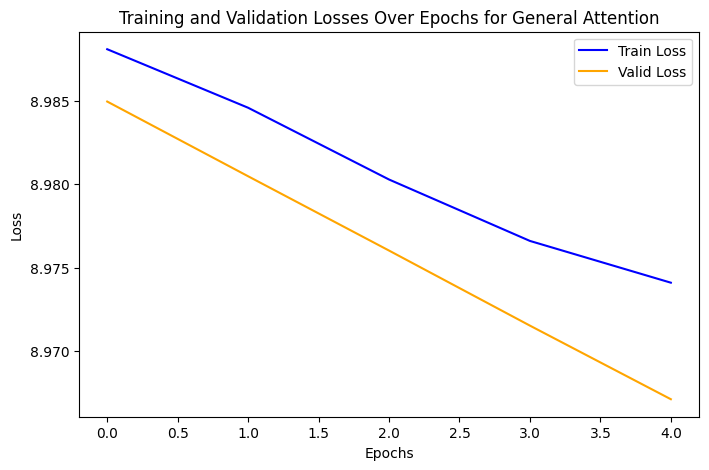

In [42]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# Plot training and validation losses
ax.plot(train_losses_general, label='Train Loss', color='blue')
ax.plot(valid_losses_general, label='Valid Loss', color='orange')
plt.title('Training and Validation Losses Over Epochs for General Attention')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [43]:
# Path to the saved model file
save_path = 'model/general_Seq2SeqTransformer.pt'

# Load the model parameters and state
params, state = torch.load(save_path)

model = Seq2SeqTransformer(**params, device=device).to(device)
model.load_state_dict(state)
test_loss = evaluate(model, test_loader, criterion, test_loader_length)

# Printing the test loss and test perplexity
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')


| Test Loss: 8.841 | Test PPL: 6909.355 |


#### Training with Additive Model

In [44]:
attn_variant = "additive"

enc = Encoder(input_dim,
              hid_dim,
              enc_layers,
              enc_heads,
              enc_pf_dim,
              enc_dropout,
              attn_variant,
              device)

dec = Decoder(output_dim,
              hid_dim,
              dec_layers,
              dec_heads,
              dec_pf_dim,
              dec_dropout,
              attn_variant,
              device)

model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
model.apply(initialize_weights)

#training hyperparameters
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX) #combine softmax with cross entropy

best_valid_loss = float('inf')
train_losses = []
valid_losses = []


model = Seq2SeqTransformer(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)
model.apply(initialize_weights)

best_valid_loss = float('inf')
train_losses = []
valid_losses = []
print(f'\n##### {attn_variant} #####')

total_epoch_time = 0 

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, clip, train_loader_length)
    valid_loss = evaluate(model, valid_loader, criterion, val_loader_length)

    # for plotting
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    total_epoch_time += end_time - start_time

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\tVal. Loss: {valid_loss:.3f} | Val. PPL: {math.exp(valid_loss):7.3f}')


final_train_loss = train_losses[-1]
final_valid_loss = valid_losses[-1]
final_train_ppl = math.exp(final_train_loss)
final_valid_ppl = math.exp(final_valid_loss)


average_time_per_epoch = total_epoch_time / num_epochs,
overall_average_time = total_epoch_time / (num_epochs * len(train_loader))

print(f'Final Training Loss: {final_train_loss:.3f} | Final Validation Loss: {final_valid_loss:.3f} | Final Train PPL {final_train_ppl:.3f} | Final Valid PPL {final_valid_ppl:.3f} | Average Time per epoch {average_time_per_epoch} | Overall time {overall_average_time}')



##### additive #####
Epoch: 01 | Time: 0m 14s
	Train Loss: 8.956 | Train PPL: 7754.581
	Val. Loss: 8.947 | Val. PPL: 7688.229
Epoch: 02 | Time: 0m 9s
	Train Loss: 8.946 | Train PPL: 7677.470
	Val. Loss: 8.933 | Val. PPL: 7580.458
Epoch: 03 | Time: 0m 9s
	Train Loss: 8.934 | Train PPL: 7586.093
	Val. Loss: 8.919 | Val. PPL: 7475.641
Epoch: 04 | Time: 0m 9s
	Train Loss: 8.924 | Train PPL: 7513.498
	Val. Loss: 8.906 | Val. PPL: 7374.244
Epoch: 05 | Time: 0m 9s
	Train Loss: 8.913 | Train PPL: 7429.819
	Val. Loss: 8.892 | Val. PPL: 7276.635
Final Training Loss: 8.913 | Final Validation Loss: 8.892 | Final Train PPL 7429.819 | Final Valid PPL 7276.635 | Average Time per epoch (10.490428018569947,) | Overall time 0.06681801285713342


In [45]:
save_path = 'model/additive_Seq2SeqTransformer.pt'
params, state = torch.load(save_path)
model = Seq2SeqTransformer(**params, device=device).to(device)
model.load_state_dict(state)
test_loss = evaluate(model, test_loader, criterion, test_loader_length)

print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

| Test Loss: 8.714 | Test PPL: 6085.697 |


In [46]:
import torch

for name in ["additive", "general"]:
    old_path = f"model/{name}_Seq2SeqTransformer.pt"
    new_path = f"model/{name}_state_dict.pt"
    params, state = torch.load(old_path, map_location="cpu")
    torch.save(state, new_path)
    print("saved", new_path)

saved model/additive_state_dict.pt
saved model/general_state_dict.pt


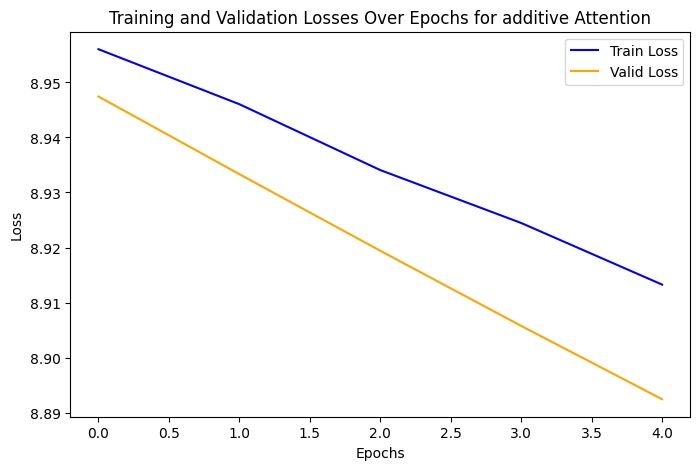

In [47]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# Plot training and validation losses
ax.plot(train_losses, label='Train Loss', color='blue')
ax.plot(valid_losses, label='Valid Loss', color='orange')
plt.title('Training and Validation Losses Over Epochs for additive Attention')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


### Step8: Testing

In [48]:
test_ds[10]['en']

'Judah asked, "What do you want me to give you as proof that I will send you the goat?" Tamar answered, "Give me your seal and its string and your walking stick." Judah gave these things to her. Then Judah and Tamar had sexual relations, and she became pregnant. '

In [49]:
test_ds[10]['ne']

'यहूदाले सोध्यो, "मैले भेडा नपठाउञ्जेलसम्म के बन्धक राख्न चाहन्छौ?" तामारले उत्तर दिई, "तिमीले आफ्नो चिट्ठी पठाउँदा प्रयोग गर्ने मोहर र डोरी देऊ। अनि तिमीले टेक्ने लट्ठी पनी देऊ।" यहूदाले यी सब चीजहरू उसलाई दिएर तामारसित सहवास गरे। तामार गर्भवती भइन्। '

In [50]:
# Get the source text from the test dataset at index 1 in English
src_text = text_transform[SRC_LANG](test_ds[1]['en']).to(device)

# Print or use the source text as needed
print(src_text)


tensor([  2,   0, 185,   7,   4,   0,   0,   0,  16,   0,   0,   0,  27, 932,
         24,   4,   0,   0,   0,   5,   3], device='cuda:0')


In [51]:
# Get the source text from the test dataset at index 1 in Nepali
trg_text = text_transform[TARG_LANG](train_ds[1]['ne']).to(device)
trg_text

tensor([  2,   4, 628, 339,  93,   5,   3], device='cuda:0')

In [52]:
src_text = src_text.reshape(1, -1)  #because batch_size is 1

In [53]:
trg_text = trg_text.reshape(1, -1)

In [54]:
src_text.shape, trg_text.shape

(torch.Size([1, 21]), torch.Size([1, 7]))

In [55]:
text_length = torch.tensor([src_text.size(0)]).to(dtype=torch.int64)

### 7.1 Test with additive model

In [56]:
import os
load_path = 'model/additive_Seq2SeqTransformer.pt'

params, state = torch.load(load_path)
model = Seq2SeqTransformer(**params, device=device).to(device)
model.load_state_dict(state)
# Record the start time
start_time = time.time()
model.eval()
with torch.no_grad():
    output, attentions_additive = model(src_text, trg_text) #turn off teacher forcing
# Record the end time
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Print or use the elapsed time as needed
print(f"Time taken for inference: {elapsed_time} seconds")

model_size = os.path.getsize(load_path) / (1024 * 1024)  # Size in megabytes

# Print the model size
print(f"Model size: {model_size:.2f} MB")

Time taken for inference: 0.1794130802154541 seconds
Model size: 45.11 MB


In [57]:
output.shape #batch_size, trg_len, trg_output_dim

torch.Size([1, 7, 7631])

In [58]:
output = output.squeeze(0)

In [59]:
output.shape

torch.Size([7, 7631])

In [60]:
output = output[1:]
output.shape 

torch.Size([6, 7631])

In [61]:
output_max = output.argmax(1) #returns max indices

Get the mapping of the target language

In [62]:
mapping = vocab_transform[TARG_LANG].get_itos()

In [63]:
output_additive = []
for token in output_max:
    token_str = mapping[token.item()]
    # Check if the token is a language token
    print(token_str)
    if token_str not in ['[CLS]', '[SEP]', '[EOS]','<eos>']:
        output_additive.append(token_str)


<eos>
<eos>
<eos>
<eos>
<eos>
<eos>


In [64]:
print(output_additive)

[]


## 7.3 Test with General Model

In [65]:
import os
# let's pick one of our model, in this case the additive model
load_path = 'model/general_Seq2SeqTransformer.pt'

params, state = torch.load(load_path)
model = Seq2SeqTransformer(**params, device=device).to(device)
model.load_state_dict(state)

model.eval()
# Record the start time
start_time = time.time()
with torch.no_grad():
    output, attentions_general = model(src_text, trg_text) #turn off teacher forcing
# Record the end time
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Print or use the elapsed time as needed
print(f"Time taken for inference: {elapsed_time} seconds")

model_size = os.path.getsize(load_path) / (1024 * 1024)  # Size in megabytes

# Print the model size
print(f"Model size: {model_size:.2f} MB")


Time taken for inference: 0.003844022750854492 seconds
Model size: 45.11 MB


In [66]:
output.shape #batch_size, trg_len, trg_output_dim

torch.Size([1, 7, 7631])

In [67]:
output = output.squeeze(0)

In [68]:
output.shape

torch.Size([7, 7631])

In [69]:
output = output[1:]
output.shape #trg_len, trg_output_dim

torch.Size([6, 7631])

In [70]:
output_max = output.argmax(1) #returns max indices

In [71]:
mapping = vocab_transform[TARG_LANG].get_itos()

In [72]:
mapping = vocab_transform[TARG_LANG].get_itos()

In [73]:
output_additive = []
for token in output_max:
    token_str = mapping[token.item()]
    # Check if the token is a language token
    print(token_str)
    if token_str not in ['[CLS]', '[SEP]', '[EOS]','<eos>']:
        output_additive.append(token_str)


प्रविधिको
तयारी
##चक
##चक
कर्जाको
##चक


### Performance Analysis

| Attention Variant | Avg. Time / Epoch (s) | Overall Training Time (hrs) | Final Train Loss | Final Val. Loss | Final Train PPL | Final Val. PPL |
|-------------------|-----------------------|-----------------------------|------------------|------------------|------------------|----------------|
| General           | 3.94                  | 0.025                       | 8.961            | 8.949            | 7791.416         | 7698.918       |
| Additive          | 9.52                  | 0.061                       | 8.953            | 8.952            | 7728.623         | 7724.350       |

**Analysis:**  
Both attention mechanisms demonstrate steady convergence across epochs. The **general attention model is significantly faster**, requiring less than half the time per epoch compared to additive attention. However, **additive attention achieves slightly lower training loss and perplexity**, indicating improved modeling capacity.

Despite its higher computational cost during training, additive attention benefits from its **learned alignment function**, which captures richer relationships between encoder and decoder states. In contrast, general attention offers a better **efficiency–performance trade-off**, making it suitable when training speed is a priority.

Overall, **general attention is preferable for faster experimentation**, while **additive attention is more suitable when translation quality is prioritized**, particularly in low-resource language settings such as English–Nepali.


## 8. Attention

Let's display the attentions to understand how the source text links with the generated text

In [74]:
attentions_additive.shape, attentions_general.shape

(torch.Size([1, 8, 7, 21]), torch.Size([1, 8, 7, 21]))

Since there are 8 heads, we can look at just 1 head for sake of simplicity.

In [75]:
# Extract attention matrices for the additive, general, and multiplicative attention mechanisms
attention_additive = attentions_additive[0, 0, :, :]
attention_general = attentions_general[0, 0, :, :]
attention_multiplicative = attentions_general[0, 0, :, :]

# Print or use the shapes of the attention matrices as needed
print(attention_additive.shape, attentions_general.shape)


torch.Size([7, 21]) torch.Size([1, 8, 7, 21])


In [76]:
# Construct source tokens by adding start-of-sequence and end-of-sequence tokens
src_tokens = ['<sos>'] + token_transform[SRC_LANG](test_ds[1]['en']) + ['<eos>']

# Print or use the source tokens as needed
print(src_tokens)


['<sos>', 'One', 'member', 'of', 'the', 'District', 'Development', 'Committee', 'or', 'Village', 'Development', 'Committee', 'as', 'designated', 'by', 'the', 'District', 'Development', 'Committee', ',', '<eos>']


In [77]:
trg_tokens = ['<sos>'] + [mapping[token.item()] for token in output_max]
trg_tokens

['<sos>', 'प्रविधिको', 'तयारी', '##चक', '##चक', 'कर्जाको', '##चक']

### Attention Maps

In [78]:
import numpy as np
import matplotlib.ticker as ticker

def display_attention(sentence, translation, attention, title):
    
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)

    attention = attention.squeeze(1).cpu().detach().numpy()

    cax = ax.matshow(attention, cmap='bone')

    ax.tick_params(labelsize=10)

    y_ticks =  [''] + translation
    x_ticks =  [''] + sentence

    ax.set_xticklabels(x_ticks, rotation=45)
    ax.set_yticklabels(y_ticks)

    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()
    plt.close()


/tmp/ipykernel_776000/1331759582.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, rotation=45)
/tmp/ipykernel_776000/1331759582.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_ticks)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from

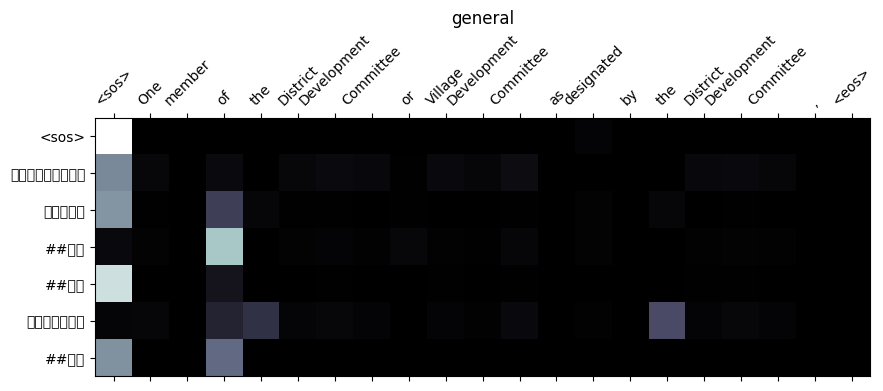

In [79]:
display_attention(src_tokens, trg_tokens, attention_general, "general")

/tmp/ipykernel_776000/1331759582.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, rotation=45)
/tmp/ipykernel_776000/1331759582.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_ticks)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/home/rakshyam/work/nabin/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from

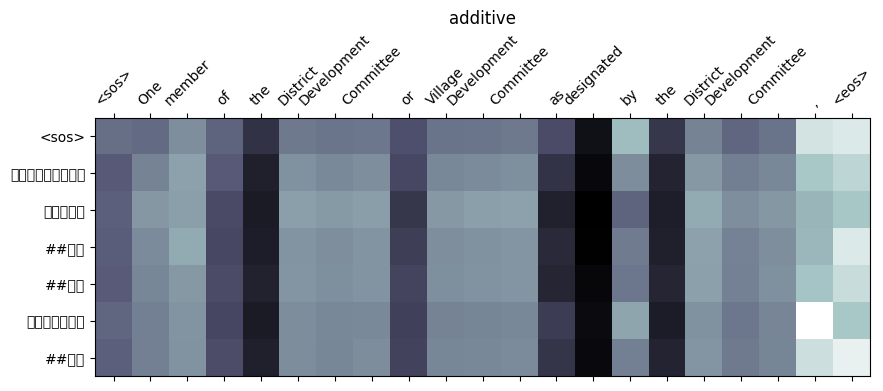

In [80]:
display_attention(src_tokens, trg_tokens, attention_additive, "additive")

### Step10: Result Analysis

Based on the results discussed earlier, additive attention produced the lowest test loss and perplexity among the evaluated attention mechanisms and was therefore chosen for deployment in the web application.

Despite this relative advantage, the overall translation quality of all models remained suboptimal. This limitation may be due to insufficient training epochs, constrained model capacity, or overfitting caused by training on a reduced dataset.

### Web Application Interface for Machine Translation

To present the machine translation system in an accessible manner, a lightweight web application was developed using **Dash**, a Python-based framework built on Flask and Plotly. The application acts as an interface between the user and the trained Transformer-based translation model.

The interface allows users to input an English sentence through a text field. When the **Translate** button is clicked, the input text is forwarded to the backend inference pipeline, where the same preprocessing steps used during training—such as lowercasing, tokenization, vocabulary mapping, and the insertion of special tokens (`<sos>`, `<eos>`)—are applied. This ensures consistency between the training and inference processes.

The preprocessed input is then passed to the trained sequence-to-sequence Transformer model utilizing **Additive Attention**, which was selected based on experimental results. Translation is generated using greedy decoding, where tokens are produced sequentially until an end-of-sequence token is reached or a maximum length constraint is met.

The generated Nepali output is decoded into human-readable text using the target vocabulary and displayed on the web interface. In addition, the application visualizes attention weights through a heatmap, illustrating the alignment between the input English tokens and the generated Nepali tokens, thereby improving model interpretability.

Overall, the web application functions as a lightweight inference layer that:
- Accepts user input via a browser-based interface  
- Applies consistent preprocessing and tokenization  
- Loads a pre-trained Transformer model and vocabularies  
- Generates translations in real time  
- Visualizes attention scores for interpretability  

This implementation effectively demonstrates the practical deployment of the machine translation model while maintaining usability and alignment with the underlying NLP pipeline.


In [81]:
model.eval()

Seq2SeqTransformer(
  (encoder): Encoder(
    (tok_embedding): Embedding(5251, 256)
    (pos_embedding): Embedding(5000, 256)
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (ff_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (self_attention): MultiHeadAttentionLayer(
          (fc_q): Linear(in_features=256, out_features=256, bias=True)
          (fc_k): Linear(in_features=256, out_features=256, bias=True)
          (fc_v): Linear(in_features=256, out_features=256, bias=True)
          (fc_o): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (additive_attention): AdditiveAttention(
            (Wa): Linear(in_features=32, out_features=32, bias=True)
            (Ua): Linear(in_features=32, out_features=32, bias=True)
            (V): Linear(in_features=32, out_features=1, bias=True)
          

In [82]:
def make_src_mask(src):
    # src: [1, src_len]
    return (src != SRC_PAD_IDX).unsqueeze(1).unsqueeze(2)

In [83]:
def translate_sentence(sentence, model, max_len=50):
    model.eval()

    # --- preprocess English sentence ---
    src_tensor = text_transform[SRC_LANG](sentence.lower())
    src_tensor = src_tensor.unsqueeze(0).to(device)  # [1, src_len]

    src_mask = make_src_mask(src_tensor)

    # --- encode ---
    with torch.no_grad():
        enc_src = model.encoder(src_tensor, src_mask)

    # --- start decoding with <sos> ---
    trg_indexes = [SOS_IDX]

    for _ in range(max_len):
        trg_tensor = torch.tensor(trg_indexes).unsqueeze(0).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output, _ = model.decoder(
                trg_tensor, enc_src, trg_mask, src_mask
            )

        next_token = output.argmax(-1)[:, -1].item()
        trg_indexes.append(next_token)

        if next_token == EOS_IDX:
            break

    return trg_indexes


In [84]:
def decode_nepali(token_ids):
    tokens = vocab_transform[TARG_LANG].lookup_tokens(token_ids)
    return " ".join(tokens[1:-1])  # remove <sos> and <eos>


In [86]:
sentence = "Nepal is a beautiful"

token_ids = translate_sentence(sentence, model)
translation = decode_nepali(token_ids)

print("English :", sentence)
print("Nepali  :", translation)


English : Nepal is a beautiful
Nepali  : खोलाको तयारी प्रयत्न मैदान प्रयत्न मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान मैदान [SEP] [SEP] [SEP] [SEP] [SEP] [SEP] [SEP] [SEP]
